In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

In [8]:
def load_data(folder="knn-dataset"):
    """
    Load inputs and targets from the csv files and store
    """
    train_inputs = pd.read_csv(os.path.join(folder, "train_inputs.csv"), header=None).values
    train_targets = pd.read_csv(os.path.join(folder, "train_labels.csv"), header=None).values.ravel()
    test_inputs = pd.read_csv(os.path.join(folder, "test_inputs.csv"), header=None).values
    test_targets = pd.read_csv(os.path.join(folder, "test_labels.csv"), header=None).values.ravel()
    return train_inputs, train_targets, test_inputs, test_targets

train_inputs, train_targets, test_inputs, test_targets = load_data()
print(train_inputs)

[[ 0.  0. 10. ...  7.  2.  2.]
 [ 0.  0.  9. ...  4.  0. 14.]
 [10. 15. 16. ... 14. 16.  1.]
 ...
 [ 5.  2.  0. ...  1.  4.  4.]
 [ 0.  0.  5. ...  0.  4.  2.]
 [ 0.  0.  2. ...  0.  2.  0.]]


In [9]:
def euclidean_distance(x1, x2):
    """
    calculates the euclidean distance between a point and a set of points
    """
    return np.sqrt(np.sum((x1 - x2) ** 2, axis=1))


class KNNClassifier:
    def __init__(self, k=3):
        self.k = k
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    
    def predict(self, X):
        # predicts the class labels for a given set of input samples
        predictions = []
        for x in X:
            # compute the distances and get the indices and labels of the k nearest neighbors, determine a most common label
            distances = euclidean_distance(self.X_train, x)
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = self.y_train[k_indices]
            most_common = np.bincount(k_nearest_labels.astype(int)).argmax()
            predictions.append(most_common)
        return np.array(predictions)

# 10-Fold Cross Validation
def cross_validate(X, y, k_values, folds=10):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    avg_accuracies = []
    
    for k in k_values:
        knn = KNNClassifier(k)
        fold_accuracies = []
        for train_idx, val_idx in kf.split(X):
            # split the data into the training and validation sets
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            # train the model and evaluate on the validation set
            knn.fit(X_train, y_train)
            predictions = knn.predict(X_val)
            accuracy = np.mean(predictions == y_val)
            fold_accuracies.append(accuracy)
        # get the average accuracy for this k in k_values
        avg_accuracies.append(np.mean(fold_accuracies))
    
    return avg_accuracies

k_values = range(1, 31)
avg_accuracies = cross_validate(train_inputs, train_targets, k_values)
print(avg_accuracies)

[np.float64(0.756), np.float64(0.759), np.float64(0.785), np.float64(0.792), np.float64(0.79), np.float64(0.792), np.float64(0.789), np.float64(0.794), np.float64(0.783), np.float64(0.79), np.float64(0.7929999999999999), np.float64(0.796), np.float64(0.788), np.float64(0.794), np.float64(0.799), np.float64(0.794), np.float64(0.798), np.float64(0.797), np.float64(0.789), np.float64(0.786), np.float64(0.777), np.float64(0.7870000000000001), np.float64(0.7750000000000001), np.float64(0.783), np.float64(0.784), np.float64(0.7750000000000001), np.float64(0.775), np.float64(0.782), np.float64(0.781), np.float64(0.783)]


In [10]:
best_k = k_values[np.argmax(avg_accuracies)]
best_accuracy = max(avg_accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 15
Best Accuracy: 0.799


In [11]:
knn_best = KNNClassifier(best_k)
knn_best.fit(train_inputs, train_targets)
test_predictions = knn_best.predict(test_inputs)
test_accuracy = np.mean(test_predictions == test_targets)
print(test_predictions)
print("Test Accuracy:", test_accuracy)

[6 6 5 6 6 6 5 5 5 6 5 6 6 6 6 6 6 5 5 6 6 6 5 6 5 6 5 5 6 5 6 6 6 6 6 6 5
 6 5 5 6 6 5 6 6 5 6 5 6 5 6 6 6 6 6 5 5 5 5 6 5 6 6 6 6 6 5 5 5 6 5 6 6 5
 6 5 6 5 6 6 5 6 6 5 6 5 6 6 5 6 6 6 6 6 6 6 6 6 5 6 6 6 6 6 6 6 5 6 5 6]
Test Accuracy: 0.7727272727272727


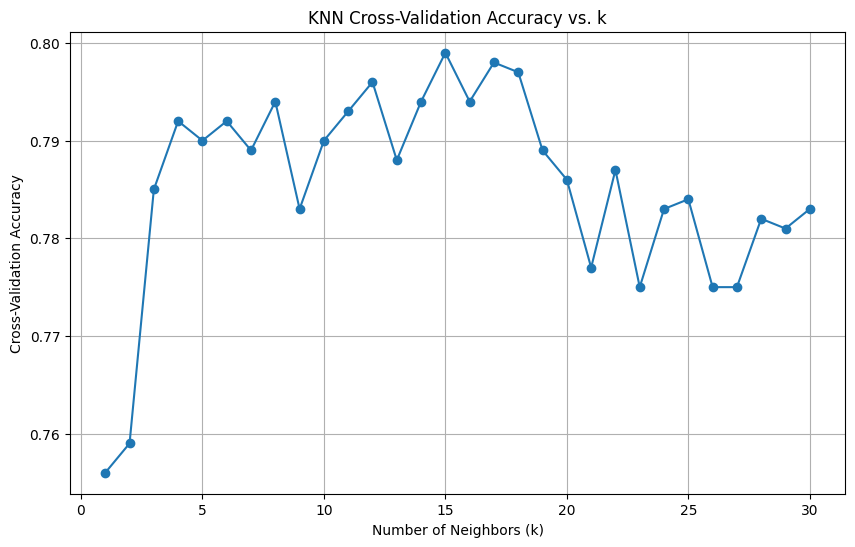

Best k: 15, Cross-validation Accuracy: 0.7990
Test Accuracy with k=15: 0.7727


In [12]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, avg_accuracies, marker='o', linestyle='-')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN Cross-Validation Accuracy vs. k')
plt.grid()
plot_folder = "plots"
plt.savefig(os.path.join(plot_folder, "KNN Cross-Validation Accuracy vs. K.png"))
plt.show()

# Print results
print(f"Best k: {best_k}, Cross-validation Accuracy: {best_accuracy:.4f}")
print(f"Test Accuracy with k={best_k}: {test_accuracy:.4f}")